# Car Price Prediction with Machine Learning

## Introduction
This project is developed as part of the CodeAlpha Data Science Internship.

The objective is to build a regression model that predicts the selling price of a used car based on features like the car's age, present showroom price, kilometers driven, fuel type, seller type, transmission, and ownership history.

## Problem Statement
Used car pricing depends on multiple factors including depreciation, mileage, brand, and condition. This project builds a regression model to predict the `Selling_Price` of a car using its other attributes, helping buyers and sellers estimate a fair resale value.

## Dataset Description
The dataset contains 301 used car listings (model years 2003–2018) with the following columns:
- Car_Name — model name of the car
- Year — year of manufacture
- Selling_Price — price at which the car was sold (target variable, in Lakhs INR)
- Present_Price — current ex-showroom price (Lakhs INR)
- Kms_Driven — total kilometers driven
- Fuel_Type — Petrol / Diesel / CNG
- Seller_Type — Dealer / Individual
- Transmission — Manual / Automatic
- Owner — number of previous owners


## 1. Import Libraries

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

## 2. Data Loading

In [24]:
df = pd.read_csv("car_prediction_data.csv")
print("Shape:", df.shape)
df.head()

Shape: (301, 9)


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


## 3. Data Exploration

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [26]:
df.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [27]:
df.isnull().sum()

,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Kms_Driven,0
Fuel_Type,0
Seller_Type,0
Transmission,0
Owner,0


In [28]:
df["Car_Name"].nunique()

98

## 4. Exploratory Data Analysis

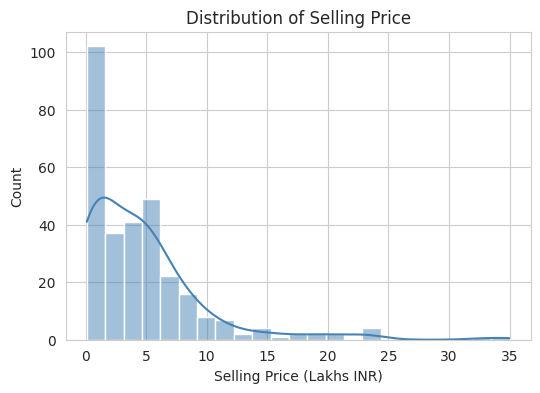

In [29]:
plt.figure(figsize=(6, 4))
sns.histplot(df["Selling_Price"], kde=True, color="steelblue")
plt.title("Distribution of Selling Price")
plt.xlabel("Selling Price (Lakhs INR)")
plt.show()

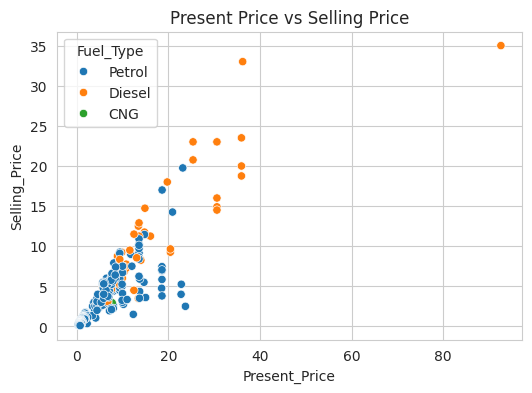

In [30]:
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x="Present_Price", y="Selling_Price", hue="Fuel_Type")
plt.title("Present Price vs Selling Price")
plt.show()

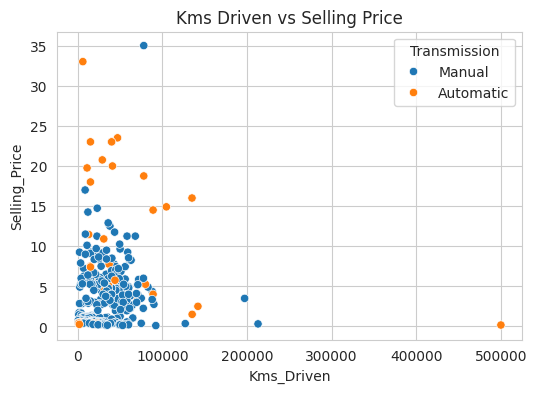

In [31]:
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x="Kms_Driven", y="Selling_Price", hue="Transmission")
plt.title("Kms Driven vs Selling Price")
plt.show()

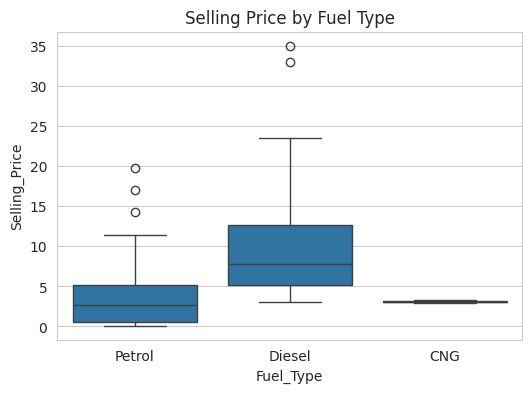

In [32]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x="Fuel_Type", y="Selling_Price")
plt.title("Selling Price by Fuel Type")
plt.show()

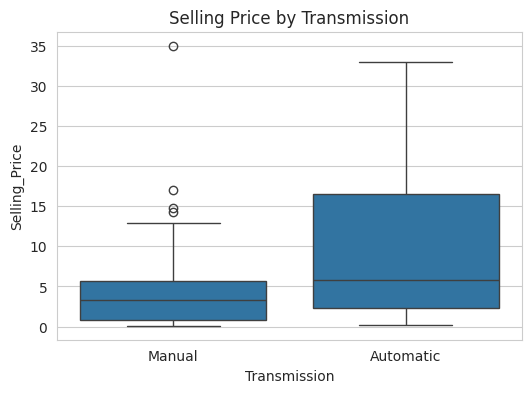

In [33]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x="Transmission", y="Selling_Price")
plt.title("Selling Price by Transmission")
plt.show()

/tmp/ipykernel_611/4062161556.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_models.values, y=top_models.index, palette="viridis")


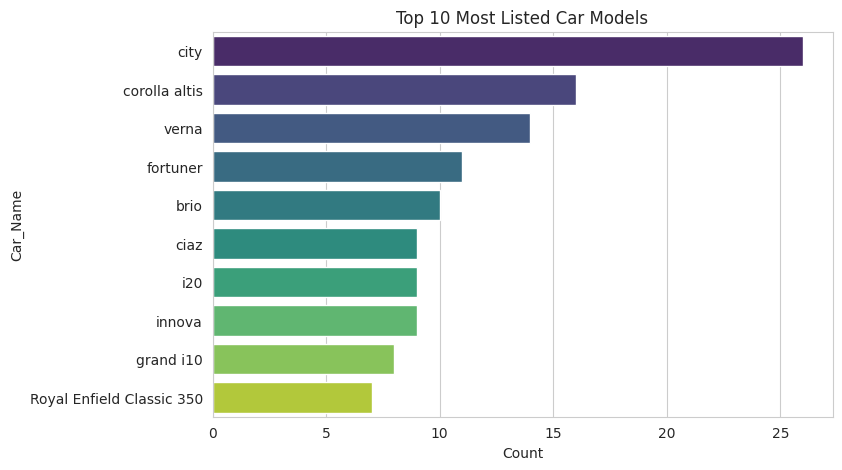

In [34]:
top_models = df["Car_Name"].value_counts().head(10)
plt.figure(figsize=(8, 5))
sns.barplot(x=top_models.values, y=top_models.index, palette="viridis")
plt.title("Top 10 Most Listed Car Models")
plt.xlabel("Count")
plt.show()

## 5. Feature Engineering

We convert `Year` into `Car_Age` (more directly related to depreciation), and one-hot encode the categorical columns. `Car_Name` is dropped due to high cardinality (98 unique values).

In [35]:
# Create Car_Age feature (dataset is from ~2020)
current_year = 2020
df["Car_Age"] = current_year - df["Year"]

# Drop columns not used for modeling
df_model = df.drop(["Car_Name", "Year"], axis=1)

df_model.head()

,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Car_Age
0,3.35,5.59,27000,Petrol,Dealer,Manual,0,6
1,4.75,9.54,43000,Diesel,Dealer,Manual,0,7
2,7.25,9.85,6900,Petrol,Dealer,Manual,0,3
3,2.85,4.15,5200,Petrol,Dealer,Manual,0,9
4,4.60,6.87,42450,Diesel,Dealer,Manual,0,6


In [36]:
# One-hot encode categorical columns
df_model = pd.get_dummies(df_model, columns=["Fuel_Type", "Seller_Type", "Transmission"], drop_first=True)
df_model.head()

,Selling_Price,Present_Price,Kms_Driven,Owner,Car_Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
0,3.35,5.59,27000,0,6,False,True,False,True
1,4.75,9.54,43000,0,7,True,False,False,True
2,7.25,9.85,6900,0,3,False,True,False,True
3,2.85,4.15,5200,0,9,False,True,False,True
4,4.60,6.87,42450,0,6,True,False,False,True


## 6. Correlation Analysis

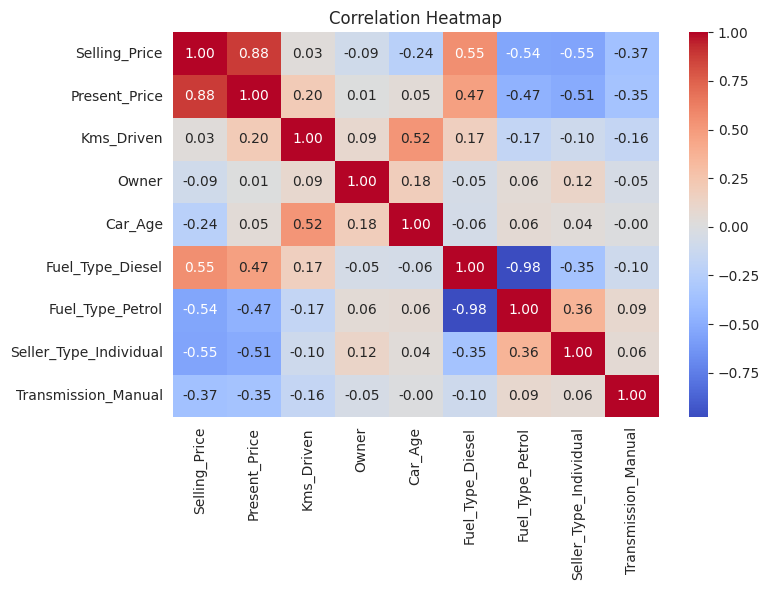

In [37]:
plt.figure(figsize=(8, 6))
sns.heatmap(df_model.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

## 7. Prepare Data for Modeling

In [38]:
X = df_model.drop("Selling_Price", axis=1)
y = df_model["Selling_Price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (240, 8)
Testing set: (61, 8)


## 8. Model Training & Comparison

We train three regression models and compare their performance using R² score and error metrics.

In [39]:
models = {
    "Linear Regression": LinearRegression(),
    "Lasso Regression": Lasso(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    results[name] = {"MAE": mae, "RMSE": rmse, "R2": r2}
    print(f"{name} -> MAE: {mae:.3f}, RMSE: {rmse:.3f}, R2: {r2:.3f}")

Linear Regression -> MAE: 1.216, RMSE: 1.865, R2: 0.849
Lasso Regression -> MAE: 1.471, RMSE: 2.154, R2: 0.799
Decision Tree -> MAE: 0.862, RMSE: 1.434, R2: 0.911
Random Forest -> MAE: 0.639, RMSE: 0.960, R2: 0.960


In [40]:
results_df = pd.DataFrame(results).T
results_df

,MAE,RMSE,R2
Linear Regression,1.216226,1.865155,0.848981
Lasso Regression,1.471418,2.154166,0.798554
Decision Tree,0.862459,1.434083,0.910721
Random Forest,0.638721,0.959981,0.959994


## 9. Detailed Evaluation — Random Forest

Random Forest performed best across all metrics, so we use it as our final model and examine which features drive its predictions.

In [41]:
best_model = RandomForestRegressor(random_state=42)
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

print("Final Model Performance:")
print("MAE:", round(mean_absolute_error(y_test, y_pred), 3))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, y_pred)), 3))
print("R2 Score:", round(r2_score(y_test, y_pred), 3))

Final Model Performance:
MAE: 0.639
RMSE: 0.96
R2 Score: 0.96


/tmp/ipykernel_611/1127730782.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette="mako")


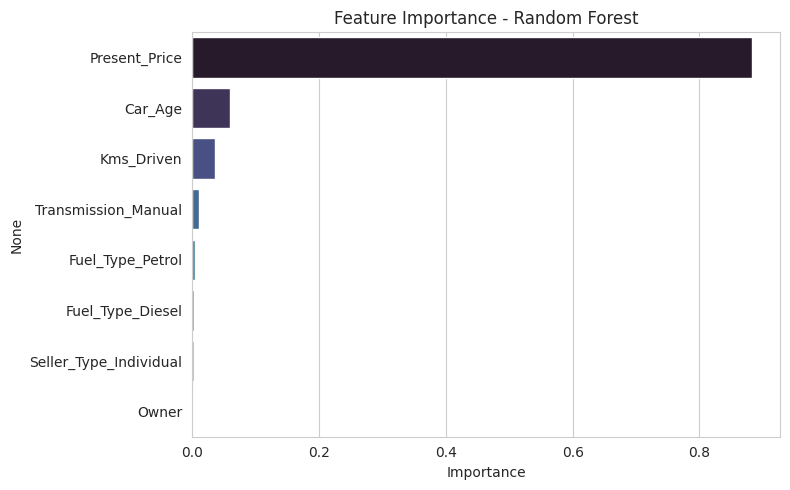

Present_Price             0.882877
Car_Age                   0.060123
Kms_Driven                0.036249
Transmission_Manual       0.010395
Fuel_Type_Petrol          0.004028
Fuel_Type_Diesel          0.002894
Seller_Type_Individual    0.002083
Owner                     0.001351
dtype: float64


In [42]:
importances = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=importances.values, y=importances.index, palette="mako")
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

print(importances)

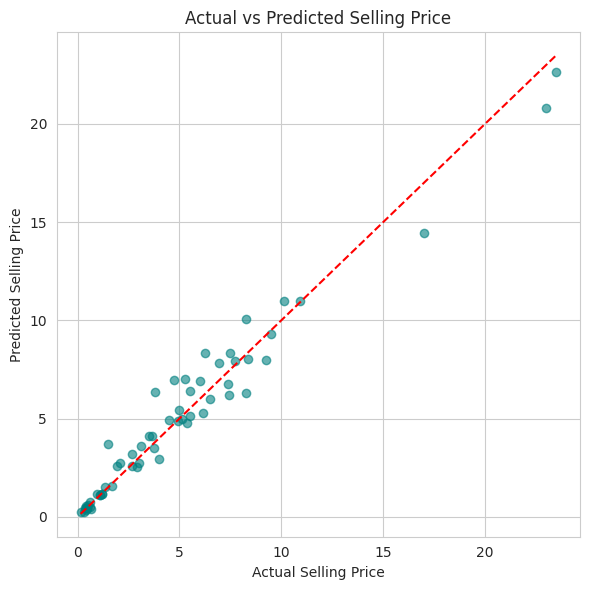

In [43]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color="teal")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual vs Predicted Selling Price")
plt.tight_layout()
plt.show()

## 10. Conclusion

This project built and compared multiple regression models to predict used car selling prices based on features like present price, age, mileage, fuel type, seller type, transmission, and ownership history.

**Model Comparison:**
- Linear Regression: R² = 0.849
- Lasso Regression: R² = 0.799
- Decision Tree: R² = 0.911
- **Random Forest: R² = 0.960** (best performing model)

**Final Model Performance (Random Forest):**
- MAE: 0.64 Lakhs INR
- RMSE: 0.96 Lakhs INR
- R² Score: 0.96 (explains 96% of the variance in selling price)

**Key Insights:**
- `Present_Price` (original showroom price) is by far the most influential factor in predicting resale value, accounting for ~88% of feature importance
- `Car_Age` and `Kms_Driven` play smaller but meaningful roles, consistent with the expectation that older, higher-mileage cars depreciate more
- Categorical features (fuel type, seller type, transmission) had comparatively minor influence on price once present price and age were accounted for
- The actual vs. predicted plot shows strong alignment along the diagonal, confirming the model generalizes well, with only slight underestimation at the highest price points where fewer training examples exist

**Conclusion:**
Random Forest Regression provided the most accurate and reliable predictions for used car prices in this dataset. The results confirm that a car's original price is the dominant driver of resale value, while age and mileage provide secondary adjustments. This model could be a practical tool for buyers and sellers to estimate fair used car prices in real-world scenarios.